# **Importing libraries**

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Loading dataset**

In [19]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Data Exploration**

In [20]:
df.info()
df.isnull().sum()
df["Churn"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


# **Data Cleaning**

In [21]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors ="coerce")
df=df.dropna()

df=df.drop(columns=["customerID"])

df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

# **Data Visualization (EDA)**

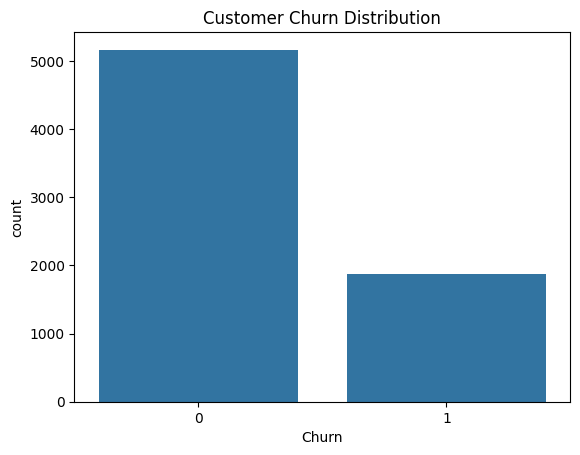

In [22]:
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

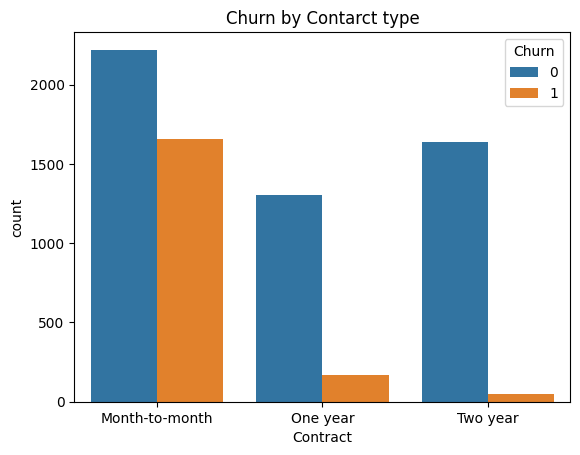

In [23]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Churn by Contarct type")
plt.show()

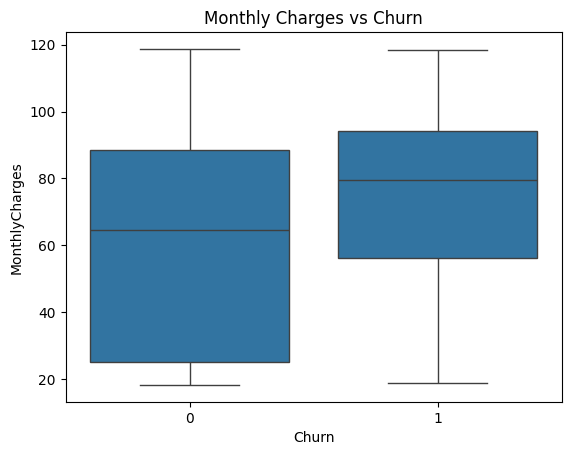

In [24]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

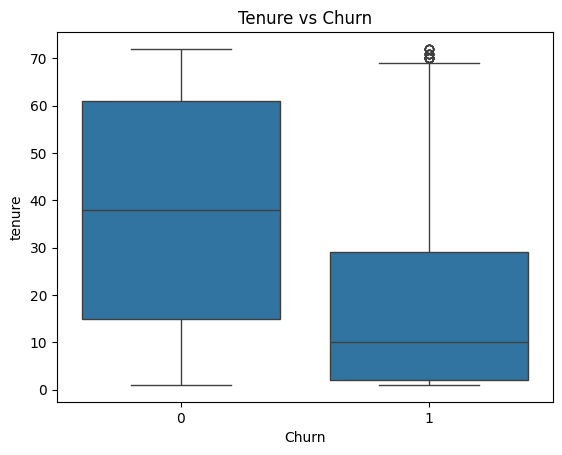

In [25]:
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title("Tenure vs Churn")
plt.show()

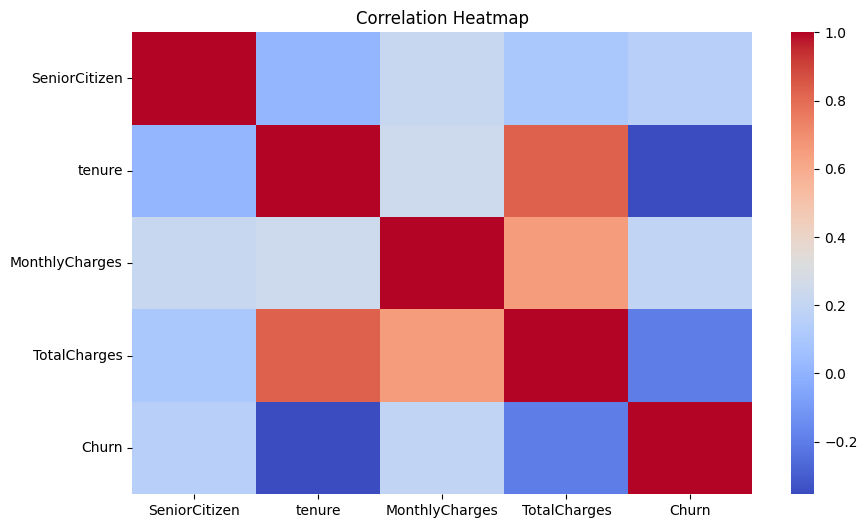

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Encoding**

In [27]:
df=pd.get_dummies(df,drop_first=True)

# **Specifying Features and Targets**

In [28]:
x=df.drop("Churn",axis=1)
y=df["Churn"]

# **Train/Test Split**

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,
                                               stratify=y,random_state=42)

# **Scalling**

In [30]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# **Logistic Regression model**

In [31]:
log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled,y_train)

y_pred_log=log_model.predict(x_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8038379530916845
[[916 117]
 [159 215]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



# **Naive Bayes**

In [32]:
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)

y_pred_nb=nb_model.predict(x_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.644633972992182
[[584 449]
 [ 51 323]]
              precision    recall  f1-score   support

           0       0.92      0.57      0.70      1033
           1       0.42      0.86      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.79      0.64      0.66      1407



# **KNN**

In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

y_pred_knn = knn_model.predict(x_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7533759772565742
[[860 173]
 [174 200]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.53      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



# **Compare Models**

In [34]:
print("Logistic Regression: ",accuracy_score(y_test,y_pred_log))
print("Naive Bayes: ",accuracy_score(y_test,y_pred_nb))
print("KNN: ",accuracy_score(y_test,y_pred_knn))

Logistic Regression:  0.8038379530916845
Naive Bayes:  0.644633972992182
KNN:  0.7533759772565742
